Data: train 1000 images -> augmentations 4000
      valid 100 images

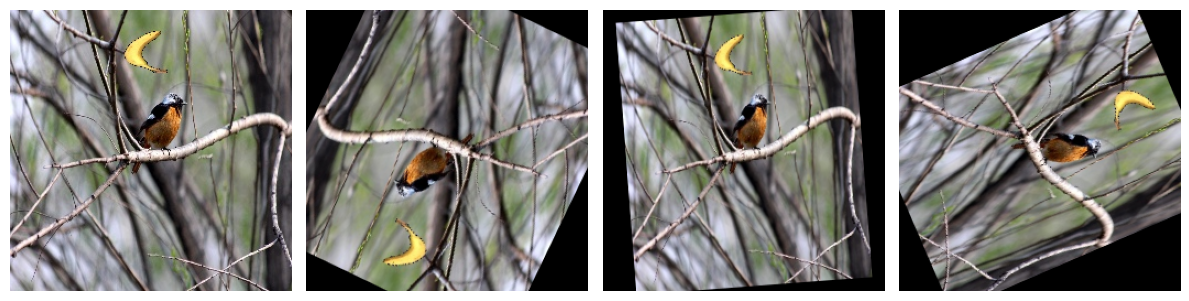

In [6]:
from PIL import Image
import matplotlib.pyplot as plt
#Data augmentation show

image_paths = [
    "banana-detection/augmented/images/0.png",
    "banana-detection/augmented/images/0_aug0.png",
    "banana-detection/augmented/images/0_aug1.png",
    "banana-detection/augmented/images/0_aug2.png",
]

fig, axes = plt.subplots(1, 4, figsize=(12, 4))

for ax, img_path in zip(axes, image_paths):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [7]:
import os
#Data loading


def decode_img(img):
    img = tf.io.decode_jpeg(img, channels=3)
    return img

def get_label(file_path):
    file_path = file_path.numpy().decode('utf-8')
    file_path = os.path.splitext(file_path)[0]
    file_name = os.path.basename(file_path)
    folder = os.path.dirname(file_path)
    label_path = f"{folder}/labels/{file_name}.txt"
    boxes = []
    if os.path.isdir(label_path):
        return tf.convert_to_tensor(boxes, dtype=tf.float32)

    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            for line in f:
                parts = list(map(float, line.strip().split()))
                if len(parts) >= 5:
                    boxes.append(parts[1:5])
    return tf.convert_to_tensor(boxes, dtype=tf.float32)


def process_path(file_path):
    img = tf.io.read_file(file_path)
    img = decode_img(img)
    boxes = tf.py_function(func=get_label, inp=[file_path], Tout=tf.float32)
    return img, boxes, file_path


def from_grid_to_coordinates(p):
    output = cxcywh_to_xyxy(p)
    return output


def cxcywh_to_xyxy(boxes):
    if boxes.shape[0] == 5:
        cx, cy, w, h, confi = tf.split(boxes, 5, axis=-1)
        x1 = cx - w / 2
        y1 = cy - h / 2
        x2 = cx + w / 2
        y2 = cy + h / 2
        return tf.concat([x1, y1, x2, y2, confi], axis=-1)
    if boxes.shape[0] == 4:
        cx, cy, w, h = tf.split(boxes, 4, axis=-1)
        x1 = cx - w / 2
        y1 = cy - h / 2
        x2 = cx + w / 2
        y2 = cy + h / 2
        return tf.concat([x1, y1, x2, y2], axis=-1)

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
#Network

def vgg_block(num_convs, out_channels):
    block = tf.keras.Sequential()
    for _ in range(num_convs):
        block.add(layers.Conv2D(out_channels, kernel_size=3, padding="same"))
        block.add(layers.BatchNormalization())
        block.add(layers.Activation("gelu"))
    block.add(layers.MaxPooling2D(pool_size=(2, 2), strides=2))
    return block


class Net(tf.keras.Model):
    def __init__(self):
        super(Net, self).__init__()

        self.conv_blks = models.Sequential([
            vgg_block(2, 32),
            vgg_block(2, 64),
            vgg_block(2, 128),
            vgg_block(2, 256),
            vgg_block(2, 512),
        ])

        self.out = tf.keras.Sequential([
            layers.Conv2D(128, kernel_size=6, padding="valid", activation="gelu"),
            layers.Dropout(0.2),
            layers.Conv2D(64, kernel_size=2, padding="valid", activation="gelu"),
            layers.Dropout(0.2),
            layers.Conv2D(1 * 5, kernel_size=2, padding="valid", activation="sigmoid")
        ])

    def build(self, input_shape):
        self.conv_blks.build(input_shape)
        x = self.conv_blks.compute_output_shape(input_shape)
        self.out.build(x)
        super(Net, self).build(input_shape)

    def call(self, x):
        x = self.conv_blks(x)
        logits = self.out(x)
        logits = tf.squeeze(logits)
        return logits


def loss_fn(labels, p):
    try:
        x_losses = tf.keras.losses.MeanSquaredError()(labels[..., 0], p[..., 0])
        y_losses = tf.keras.losses.MeanSquaredError()(labels[..., 1], p[..., 1])

        pos_losses = x_losses + y_losses

        h_loss = tf.keras.losses.MeanSquaredError()(labels[..., 2], p[..., 2])
        w_loss = tf.keras.losses.MeanSquaredError()(labels[..., 3], p[..., 3])
        size_losses = h_loss + w_loss

        total_loss = pos_losses + size_losses
        return total_loss, pos_losses, size_losses
    except Exception as e:

        return tf.constant(0.0), tf.constant(0.0), tf.constant(0.0)


In [22]:
import tensorflow as tf
from tensorflow.python.data import AUTOTUNE

from finalproject.data_loading import process_path
from finalproject.loss import loss_fn
from finalproject.network import Net

#Training run for only 1 epoch, it takes lot of time

batch_size = 6
epochs = 1
learning_rate = 1e-4

list_ds = tf.data.Dataset.list_files('banana-detection/augmented/images/*.png', shuffle=False)
train_ds = list_ds.map(process_path, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(batch_size).prefetch(buffer_size=AUTOTUNE)

val_list_ds = tf.data.Dataset.list_files('banana-detection/bananas_val/images/*.png', shuffle=False)
val_ds = val_list_ds.map(process_path, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(batch_size).prefetch(buffer_size=AUTOTUNE)

network = Net()
network.build(input_shape=(None, 256, 256, 3))

optimizer = tf.keras.optimizers.AdamW(learning_rate=learning_rate,  weight_decay=1e-4)


patience = 10
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(epochs):

    print(f"Epoch {epoch + 1}/{epochs}")
    epoch_loss_avg = tf.keras.metrics.Mean()
    pos_losses = tf.keras.metrics.Mean()
    dim_losses = tf.keras.metrics.Mean()

    for step, (images, labels, _) in enumerate(train_ds):
        with tf.GradientTape() as tape:
            predictions = network(images, training=True)
            loss_value, pos_loss, dim_loss = loss_fn(labels[:,0,:], predictions)

        gradients = tape.gradient(loss_value, network.trainable_variables)
        optimizer.apply_gradients(zip(gradients, network.trainable_variables))
        max_grad = max([tf.reduce_max(tf.abs(g)) for g in gradients if g is not None])

        if max_grad < 1e-7:
            tf.print("Warning: Possible vanishing gradients detected! Max grad =", max_grad)

        epoch_loss_avg.update_state(loss_value)
        pos_losses.update_state(pos_loss)
        dim_losses.update_state(dim_loss)

        if step % 10 == 0:
            print(f"Step {step}, Loss: {loss_value.numpy():.4f}")

    val_loss_avg = tf.keras.metrics.Mean()
    for step, (images, labels, _) in enumerate(val_ds):
        predictions = network(images, training=False)
        val_loss, _, _ = loss_fn(labels, predictions)
        val_loss_avg.update_state(val_loss)

    val_loss_value = val_loss_avg.result().numpy()

    print(f"Epoch {epoch + 1} Average Loss: {epoch_loss_avg.result().numpy():.4f}")
    print(f"Epoch {epoch + 1} Position Loss: {pos_losses.result().numpy():.4f}")
    print(f"Epoch {epoch + 1} Dimension Loss: {dim_losses.result().numpy():.4f}")
    print(f"Epoch {epoch + 1} Validation Loss: {val_loss_value:.4f}")

    network.save_weights(f'saved_model/epoch_{epoch}.weights.h5')

    if val_loss_value < best_val_loss:
        print("Validation loss improved, saving best model.")
        best_val_loss = val_loss_value
        patience_counter = 0

        network.save_weights('saved_model/best_model.weights.h5')

    else:
        patience_counter += 1
        print(f"No improvement. Patience counter: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print("Early stopping triggered!")
            break


Epoch 1/1
Step 0, Loss: 0.5361
Step 10, Loss: 0.4665
Step 20, Loss: 0.3968
Step 30, Loss: 0.1272
Step 40, Loss: 0.2336
Step 50, Loss: 0.2247
Step 60, Loss: 0.1319
Step 70, Loss: 0.1016
Step 80, Loss: 0.0817
Step 90, Loss: 0.1307
Step 100, Loss: 0.3759
Step 110, Loss: 0.0760
Step 120, Loss: 0.0496
Step 130, Loss: 0.0927
Step 140, Loss: 0.1118
Step 150, Loss: 0.0876
Step 160, Loss: 0.0275
Step 170, Loss: 0.1337
Step 180, Loss: 0.0272
Step 190, Loss: 0.1127
Step 200, Loss: 0.0450
Step 210, Loss: 0.0386
Step 220, Loss: 0.0710
Step 230, Loss: 0.0506
Step 240, Loss: 0.0675
Step 250, Loss: 0.0352
Step 260, Loss: 0.0564
Step 270, Loss: 0.0362
Step 280, Loss: 0.0421
Step 290, Loss: 0.0371
Step 300, Loss: 0.0818
Step 310, Loss: 0.0625
Step 320, Loss: 0.0743
Step 330, Loss: 0.0818
Step 340, Loss: 0.0421
Step 350, Loss: 0.0582
Step 360, Loss: 0.1168
Step 370, Loss: 0.0611
Step 380, Loss: 0.0558
Step 390, Loss: 0.0216
Step 400, Loss: 0.0397
Step 410, Loss: 0.0329
Step 420, Loss: 0.0359
Step 430, Lo

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step


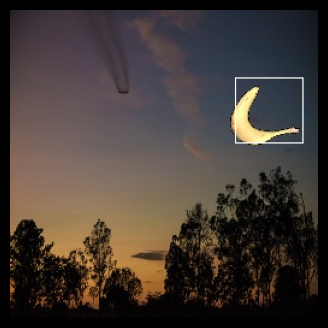

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


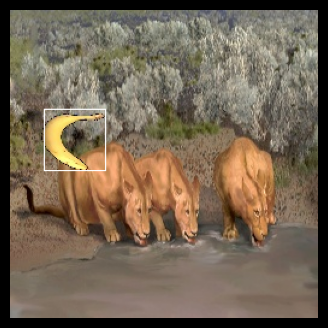

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


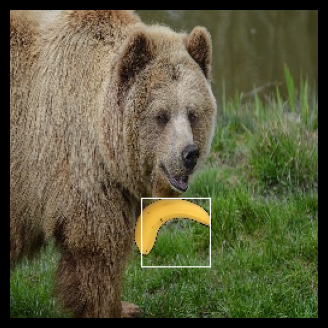

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


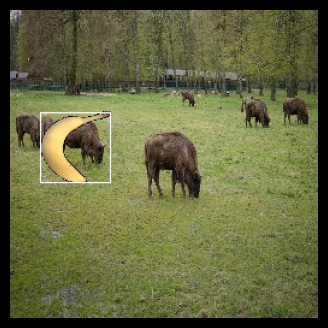

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


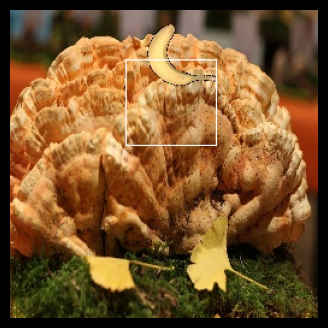

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


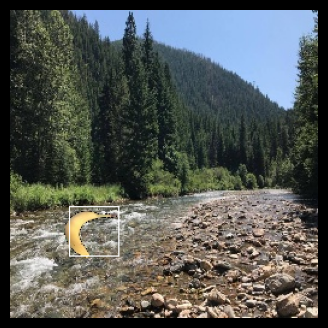

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


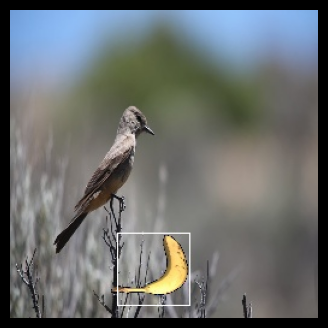

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


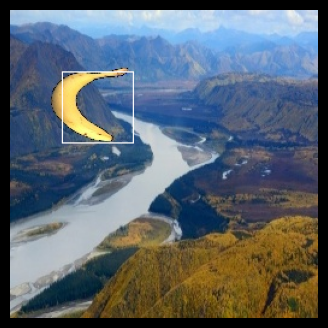

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


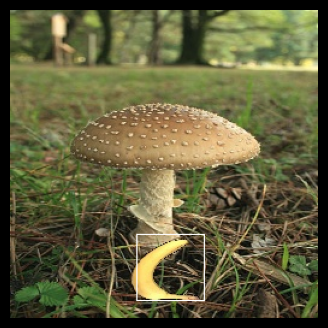

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


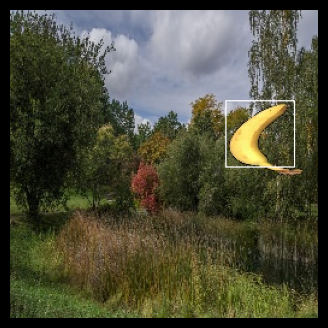

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


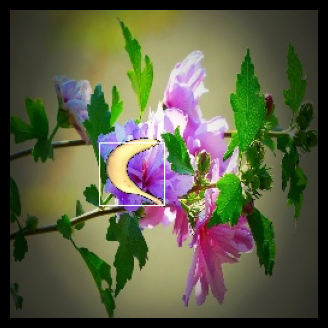

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


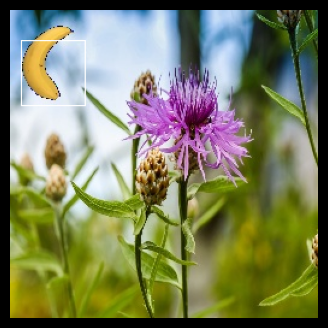

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


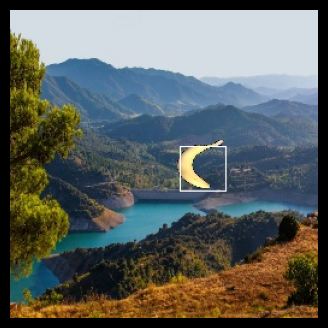

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


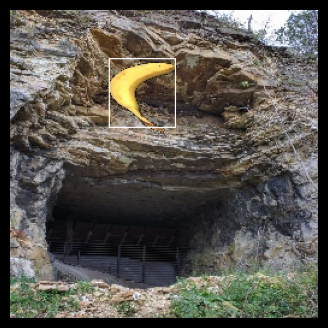

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


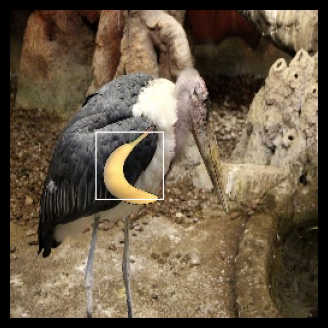

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


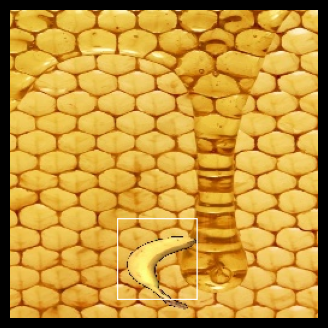

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


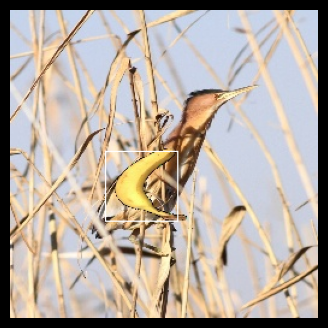

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


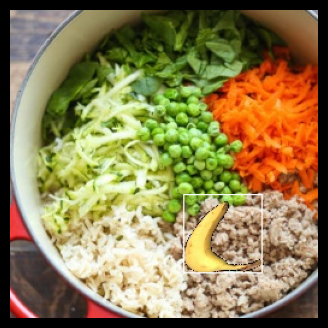

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


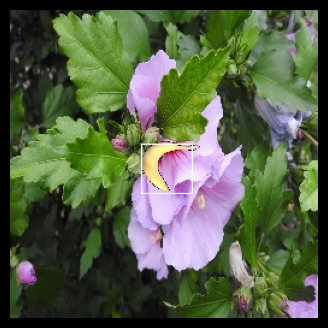

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


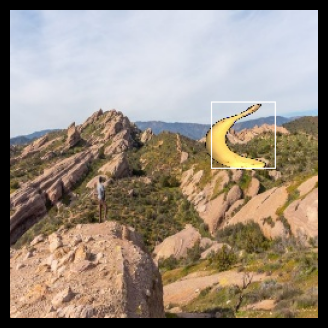

In [17]:
from pathlib import Path
from PIL import ImageDraw
from typing import Optional
import PIL
import torch
from tensorflow.python.data import AUTOTUNE
#Prediction visualization

def annotate_image(
        img,
        targets,
        labels,
        scores,
        normalized: bool = True,
        save_path: Optional[str] = None,
        file_name: Optional[str] = None,
):
    img_copy = img.copy()
    width, height = img_copy.size
    draw = ImageDraw.Draw(img_copy)

    box_width = max(1, int(min(width,
                               height) * 0.005))  # 0.5% of smaller dimension


    for box, label, conf in zip(targets, labels, scores):

        x1, y1, x2, y2, *_ = box.numpy()
        if normalized:
            x1 *= width
            x2 *= width
            y1 *= height
            y2 *= height


        draw.rectangle([x1, y1, x2, y2], width=box_width)

    if save_path and file_name:
        path = Path(save_path)
        path.mkdir(parents=True, exist_ok=True)
        full_path = path / file_name
        print("Saving annotated image to:", full_path)
        img_copy.save(full_path)

    return img_copy


def eval(mean_ap, detection, label):
    det_boxes = torch.tensor(detection.numpy(), dtype=torch.float32)
    det_scores = torch.tensor([1.0], dtype=torch.float32)
    det_labels = torch.tensor([1], dtype=torch.int64)

    label_boxes = torch.tensor(label.numpy(), dtype=torch.float32)
    label_labels = torch.tensor([1], dtype=torch.int64)

    eval_detection = {
        "boxes": det_boxes.unsqueeze(0),
        "scores": det_scores,
        "labels": det_labels
    }

    eval_label = {
        "boxes": label_boxes.unsqueeze(0),
        "labels": label_labels
    }

    mean_ap.update([eval_detection], [eval_label])


with tf.device('/CPU:0'):
    batch_size = 1

    list_ds = tf.data.Dataset.list_files('banana-detection/bananas_val/images/*.png', shuffle=False)
    val_ds = list_ds.map(process_path, num_parallel_calls=AUTOTUNE)
    val_ds = val_ds.batch(batch_size).prefetch(buffer_size=AUTOTUNE)
    model = Net()
    model.build((None, 256, 256, 3))
    model.load_weights('model/best_model.weights.h5')

    for i, (images, labels, file_path) in enumerate(val_ds.take(20)):
        prediction = model.predict(images)
        prediction = from_grid_to_coordinates(prediction)
        img = PIL.Image.open(file_path[0].numpy().decode('utf-8'))
        img = annotate_image(img, targets=tf.expand_dims(prediction, 0), scores=tf.constant([0]), labels=tf.constant([0]),
                             normalized=True)
        plt.figure(figsize=(4, 4), facecolor='black')
        plt.imshow(img)
        plt.axis('off')
        plt.show()


In [14]:
from tqdm import tqdm
from torchmetrics.detection import MeanAveragePrecision
#Map measurement

with tf.device('/CPU:0'):
    batch_size = 1

    list_ds = tf.data.Dataset.list_files('banana-detection/bananas_val/images/*.png', shuffle=False)
    val_ds = list_ds.map(process_path, num_parallel_calls=AUTOTUNE)
    val_ds = val_ds.batch(batch_size).prefetch(buffer_size=AUTOTUNE)
    ap_valid = MeanAveragePrecision(box_format='xyxy', iou_type='bbox', class_metrics=False)

    for i, (images, labels, file_path) in tqdm(enumerate(val_ds)):
        prediction = model.predict(images, verbose="0")
        prediction = from_grid_to_coordinates(prediction)
        eval(ap_valid, prediction[0:4], cxcywh_to_xyxy(labels[0][0]))

    list_ds = tf.data.Dataset.list_files('banana-detection/bananas_train/images/*.png', shuffle=False)
    train_ds = list_ds.map(process_path, num_parallel_calls=AUTOTUNE)
    train_ds = train_ds.batch(batch_size).prefetch(buffer_size=AUTOTUNE)
    ap_train = MeanAveragePrecision(box_format='xyxy', iou_type='bbox', class_metrics=False)

    for i, (images, labels, file_path) in tqdm(enumerate(train_ds)):
        prediction = model.predict(images, verbose="0")
        prediction = from_grid_to_coordinates(prediction)
        eval(ap_train, prediction[0:4], cxcywh_to_xyxy(labels[0][0]))

train_metrics = ap_train.compute()
val_metrics   = ap_valid.compute()

print(train_metrics)
print(val_metrics)




99it [00:06, 14.35it/s]2025-12-18 10:10:02.867087: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
100it [00:06, 14.63it/s]
1000it [01:15, 13.19it/s]


{'map': tensor(0.4837), 'map_50': tensor(0.9728), 'map_75': tensor(0.3657), 'map_small': tensor(0.4837), 'map_medium': tensor(-1.), 'map_large': tensor(-1.), 'mar_1': tensor(0.5788), 'mar_10': tensor(0.5788), 'mar_100': tensor(0.5788), 'mar_small': tensor(0.5788), 'mar_medium': tensor(-1.), 'mar_large': tensor(-1.), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor(1, dtype=torch.int32)}
{'map': tensor(0.4378), 'map_50': tensor(0.9400), 'map_75': tensor(0.2532), 'map_small': tensor(0.4378), 'map_medium': tensor(-1.), 'map_large': tensor(-1.), 'mar_1': tensor(0.5200), 'mar_10': tensor(0.5200), 'mar_100': tensor(0.5200), 'mar_small': tensor(0.5200), 'mar_medium': tensor(-1.), 'mar_large': tensor(-1.), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor(1, dtype=torch.int32)}


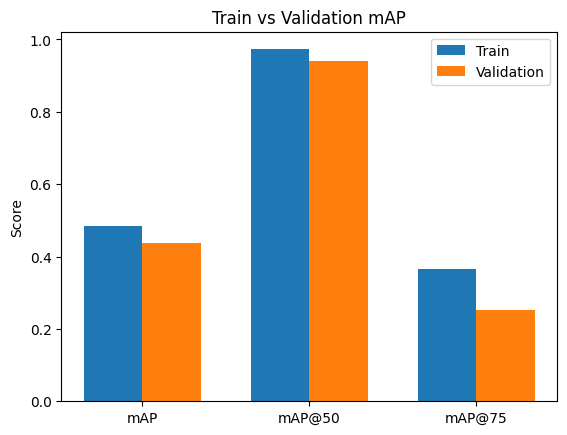

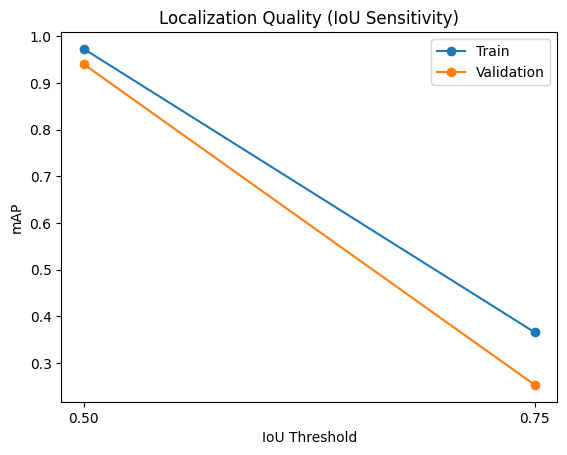

In [16]:
#Interesting figures

def plot_map_comparison(train_metrics, val_metrics):
    keys = ['map', 'map_50', 'map_75']
    train_vals = [train_metrics[k].item() for k in keys]
    val_vals   = [val_metrics[k].item() for k in keys]

    x = range(len(keys))
    width = 0.35

    plt.figure()
    plt.bar([i - width/2 for i in x], train_vals, width, label='Train')
    plt.bar([i + width/2 for i in x], val_vals,   width, label='Validation')

    plt.xticks(x, ['mAP', 'mAP@50', 'mAP@75'])
    plt.ylabel('Score')
    plt.title('Train vs Validation mAP')
    plt.legend()
    plt.show()

def plot_iou_sensitivity(train_metrics, val_metrics):
    ious = ['0.50', '0.75']
    train_vals = [
        train_metrics['map_50'].item(),
        train_metrics['map_75'].item()
    ]
    val_vals = [
        val_metrics['map_50'].item(),
        val_metrics['map_75'].item()
    ]

    plt.figure()
    plt.plot(ious, train_vals, marker='o', label='Train')
    plt.plot(ious, val_vals, marker='o', label='Validation')

    plt.xlabel('IoU Threshold')
    plt.ylabel('mAP')
    plt.title('Localization Quality (IoU Sensitivity)')
    plt.legend()
    plt.show()


plot_map_comparison(train_metrics, val_metrics)
plot_iou_sensitivity(train_metrics, val_metrics)